  0%|          | 0/5000 [00:00<?, ?it/s]

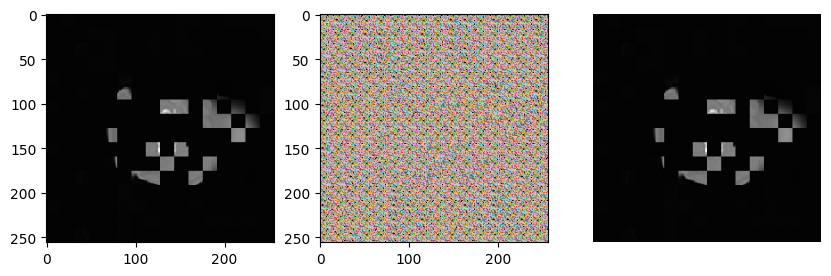

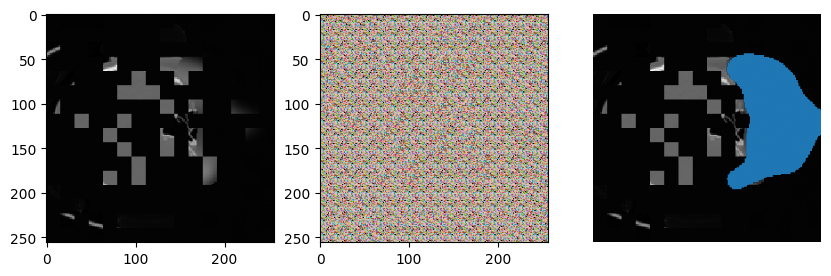

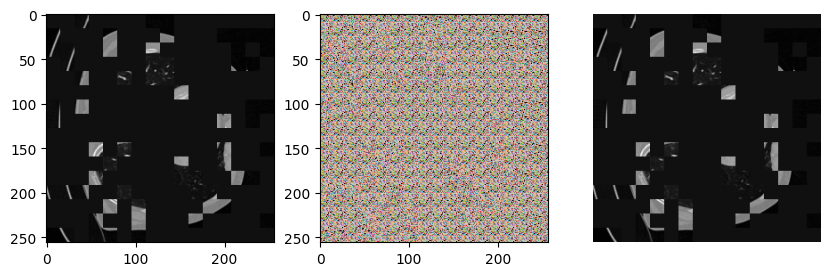

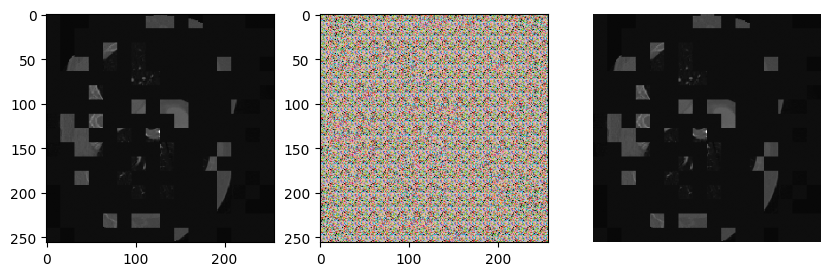

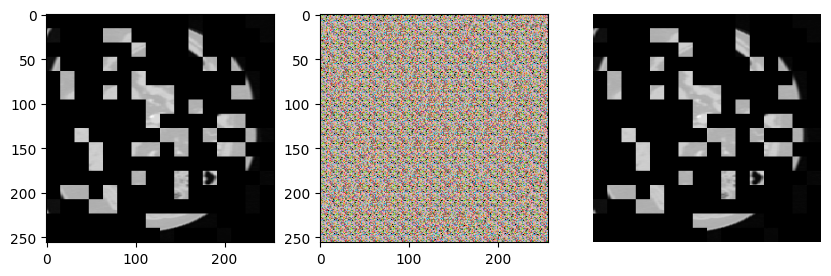

  1%|          | 49/5000 [04:38<7:46:43,  5.66s/it]

In [ ]:
import math
from tqdm import tqdm
from typing import Any
from collections import defaultdict

import torch
import wandb
import numpy as np
import plotly.express as px
from torch import nn, Tensor
import torch.nn.functional as F
from torch.optim import Optimizer, AdamW
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import LRScheduler, LambdaLR

from mae.model import *
from src import configs as cfg
from src import dataset, metrics
from mae.utils import setup_seed

# TODO:
# - Add segmentation loss
# - Add images
# - Add back training samples seen
# - Add checkpoints
# - Add evaluation
# - Add submission
# - Submit
# - Switch to one cycle lr

def main():
    # system setup
    dataset.mk_dataset(verbose=False)
    torch.backends.cuda.matmul.fp32_precision = 'ieee'
    # setup configs
    train_cfg = cfg.TrainingConfig(
        max_lr=1e-3,
        n_epochs=5000,
        batch_size=64,
    )
    setup_seed(train_cfg.random_state)
    model_cfg = cfg.ModelConfig(compile=False)
    # setup objects (no I didn't count the configs as objects...)
    model = mk_model(model_cfg, train_cfg)
    train_loader, valid_loader = mk_semi_supervised_data_loaders(train_cfg)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        # TODO: Understand the scaling of the max_lr
        lr=train_cfg.max_lr,
        betas=(0.9, 0.95),
    )
    lr_scheduler = mk_lr_scheduler(train_cfg, optimizer)
    criterion = SemiSupervisedLoss(train_cfg)
    # Initilaze weights and biases run
    wandb_init(
        model,
        cfg.WandbConfig(["pretraining", "MAE"], "pretraining"),
        model_cfg,
        train_cfg,
    )
    # start training
    train_model(
        model,
        train_cfg,
        optimizer,
        lr_scheduler,
        train_loader,
        criterion,
    )

def mk_model(model_cfg: cfg.ModelConfig, training_cfg: cfg.TrainingConfig) -> nn.Module:
    model = MAE_ViT(
        image_size=256,
        mask_ratio=training_cfg.mask_ratio,
        patch_size=16,
        emb_dim=256,
        encoder_layer=8,
        encoder_head=8,
        decoder_head=8,
        out_channels=cfg.N_CLASSES + 1,
    ).to(cfg.DEVICE)
    model.cfg = model_cfg
    return model

def mk_lr_scheduler(train_cfg: cfg.TrainingConfig, optimizer: Optimizer) -> LRScheduler:
    def lr_func(epoch: int) -> float:
        return min(
            (epoch + 1) / (train_cfg.n_epochs // 10 + 1e-8),
            0.5 * (math.cos(epoch / train_cfg.n_epochs * math.pi) + 1)
        )
    return LambdaLR(optimizer, lr_lambda=lr_func)

def mk_semi_supervised_data_loaders(train_cfg: cfg.TrainingConfig) -> tuple[DataLoader, DataLoader]:
    x_train, y_train, x_test = dataset.load_raw_dataset(cfg.DEVICE)
    if not all(map(lambda t: t.dtype == torch.uint8, (x_train, x_test, y_train))):
        raise ValueError("Not all raw tensors are of dtype uint8.")
    x_train, x_valid, y_train, y_valid = train_test_split(
        x_train,
        y_train,
        test_size=train_cfg.test_size,
    )
    x_train = torch.cat((x_train, x_test))
    y_train_fill = torch.zeros(
        x_test.shape[0], 256, 256,
        dtype=torch.uint8,
        device=y_train.device,
    )

    y_train = torch.cat((y_train, y_train_fill))
    train_dataset = TensorDataset(x_train, y_train)
    valid_dataset = TensorDataset(x_valid, y_valid)
    train_loader = DataLoader(train_dataset, train_cfg.batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, train_cfg.batch_size)
    return train_loader, valid_loader

def wandb_init(
        model: nn.Module,
        wandb_cfg: cfg.WandbConfig,
        *configs: list[Any],
    ):
    cfg_vars = {}
    for cfg in configs:
        cfg_vars |= vars(cfg)
    wandb.init(
        project="raidium-challenge",
        config={
            **cfg_vars,
            "model_class": type(model).__class__,
        },
        **vars(wandb_cfg),
    )

def train_model(
        model: torch.nn.Module,
        train_cfg: cfg.TrainingConfig,
        optimizer: torch.optim.Optimizer,
        lr_scheduler: torch.optim.lr_scheduler.LRScheduler,
        train_loader: DataLoader,
        criterion: cfg.criterion_t,
    ) -> dict[str, Tensor]:
    for epoch in tqdm(range(train_cfg.n_epochs)):
        if epoch % 50 == 0 or epoch == train_cfg.n_epochs - 1:
            eval_model(model, train_loader)
        epoch_dict = train_model_for_single_epoch(
            model,
            optimizer,
            lr_scheduler,
            train_loader,
            criterion,
        )
        wandb.log(
            data={"training/" + k: v for k, v in epoch_dict.items()},
            step=epoch,
        )

def train_model_for_single_epoch(
        model: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        lr_scheduler: torch.optim.lr_scheduler.LRScheduler,
        train_loader: torch.utils.data.DataLoader,
        criterion: cfg.criterion_t,
    ) -> dict[str, Tensor]:
    model.train()
    n_batches = len(train_loader)
    mk_epoch_buff = lambda : torch.empty(n_batches, device=cfg.DEVICE)
    epochs_steps_dicts: dict[str, Tensor] = defaultdict(mk_epoch_buff)
    for batch_i, (x, y_true) in enumerate(train_loader):
        x = dataset.preprocess_imgs(x)
        step_dict = perform_training_step(
            model,
            x,
            y_true,
            optimizer,
            criterion,
        )
        for k, v in step_dict.items():
            epochs_steps_dicts[k][batch_i] = v.detach()
    # TODO: Check if this shouldn't get called per step instead of per epoch.
    lr_scheduler.step()
    epoch_dict = {k: v.mean().item() for k, v in epochs_steps_dicts.items()}
    return epoch_dict

def perform_training_step(
        model: torch.nn.Module,
        x: Tensor,
        y_true: Tensor,
        otpimizer: torch.optim.Optimizer,
        criterion: cfg.criterion_t,
    ) -> dict[str, Tensor]:
    otpimizer.zero_grad()
    with torch.autocast(cfg.DEVICE.type, torch.bfloat16):
        predicted_img, mask = model(x)
        loss_dict = criterion(x, predicted_img, mask, y_true)
    loss_dict["loss"].backward()
    loss_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        1.0, # TODO: Hypertune this
    )
    otpimizer.step()
    return {**loss_dict, "loss_norm": loss_norm}

class SemiSupervisedLoss:
    """
    Computes a weighted average of mse loss of the images reconstruction, dice score and cross entropy.
    """
    def __init__(self, train_cfg: cfg.TrainingConfig):
        weight = metrics.get_class_weights().to(cfg.DEVICE)
        self.cross_entropy_loss = torch.nn.CrossEntropyLoss(weight=weight)
        self.train_cfg = train_cfg

    def __call__(
            self,
            x: Tensor,
            x_hat: Tensor,
            mask: Tensor,
            y_true: Tensor,
        ) -> dict[str, Tensor]:
        # reconstruction loss
        pix_wise_rec_loss = F.mse_loss(x_hat[:, 0], x[:, 0], reduction="none")
        pix_wise_rec_loss = pix_wise_rec_loss * mask[:, 0] / self.train_cfg.mask_ratio
        rec_loss = pix_wise_rec_loss.mean()
        # Create labeled samples mask to compute seg loss only on them
        seg_loss_mask = (y_true.flatten(1) != 0 ).any(dim=1)
        # Cross entropy loss
        y_pred = x_hat[:, 1:]
        y_true = y_true.long()
        ce_loss = self.cross_entropy_loss(
            y_pred[seg_loss_mask],
            y_true[seg_loss_mask],
        )
        # Dice loss
        base_d_loss = metrics.torch_dice_loss(
            y_pred[seg_loss_mask],
            y_true[seg_loss_mask],
        )
        # Weighted average
        loss = base_d_loss * self.train_cfg.dice_loss_weight          \
             + ce_loss     * self.train_cfg.cross_entropy_loss_weight \
             + rec_loss    * self.train_cfg.rec_loss_weight
        return {
            "loss": loss,
            "cross_entropy_loss": ce_loss,
            "dice_loss": base_d_loss,
            "rec_loss": rec_loss,
        }

N_IMGS_TO_PLT = 5
@torch.no_grad
def eval_model(
        model: torch.nn.Module,
        data_loader: torch.utils.data.DataLoader,
    ):
    model.eval()
    x, y_true = next(iter(data_loader))
    x = dataset.preprocess_imgs(x)
    x = x[:N_IMGS_TO_PLT]
    x_hat, mask = model(x)
    x_hat_img = x_hat[:, :1]
    mask = mask[:, :1]
    x_hat_img = x_hat_img * mask + x * (1 - mask)
    plt_seg_imgs(x, y_true, x_hat[:, 1:], mask)
    plt_recon_imgs(x, x_hat_img, mask)

def plt_recon_imgs(x: Tensor, x_hat_img: Tensor, mask: Tensor):
    img = torch.cat(
        [
            x * (1 - mask),
            x_hat_img,
            x,
        ],
        dim=0,
    )
    img = img * dataset.STD + dataset.MEAN 
    np_imgs = (
        img
        .detach()
        .cpu()
        .numpy()
        .squeeze()
    )
    fig = px.imshow(
        np_imgs,
        facet_col=0,
        facet_col_wrap=N_IMGS_TO_PLT,
        color_continuous_scale="rainbow",
    )
    fig.show()

from src.plotting import plt_sample

def plt_seg_imgs(x: Tensor, y_true: Tensor, y_pred: Tensor, mask: Tensor):
    x = x * (1 - mask)
    for i in range(min(N_IMGS_TO_PLT, len(x))):

        plt_sample(
            x[i].squeeze().detach().cpu().numpy(),
            y_pred[i].squeeze().detach().cpu().argmax(dim=0).numpy(),
            y_true[i].squeeze().detach().cpu().numpy(),
        )

if __name__ == "__main__":
    main()